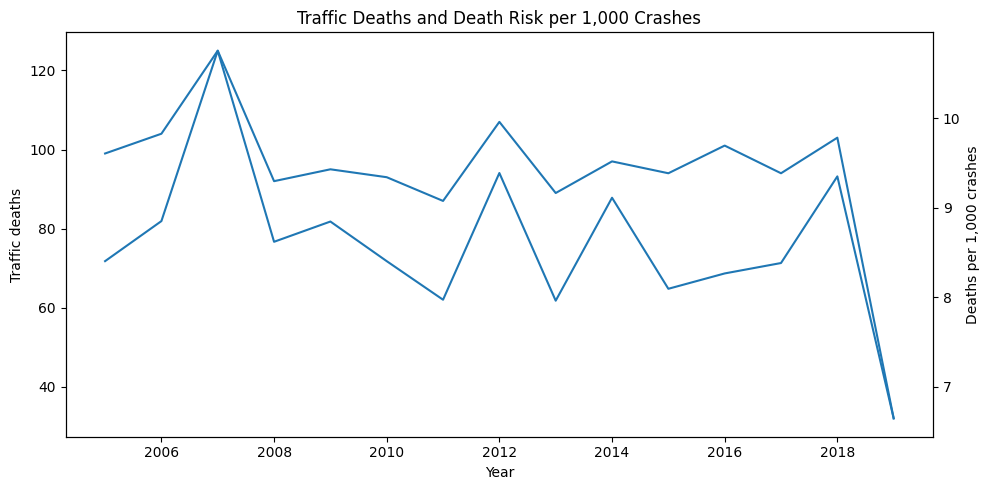

In [11]:
annual["fatalities"] = philly.groupby("CRASH_YEAR")["FATAL_COUNT"].sum()
annual["fatal_per_1000_crashes"] = annual["fatalities"] / annual["crashes"] * 1000

fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(annual.index, annual["fatalities"])
ax1.set_xlabel("Year")
ax1.set_ylabel("Traffic deaths")

ax2 = ax1.twinx()
ax2.plot(annual.index, annual["fatal_per_1000_crashes"])
ax2.set_ylabel("Deaths per 1,000 crashes")

plt.title("Traffic Deaths and Death Risk per 1,000 Crashes")
plt.tight_layout()
plt.show()


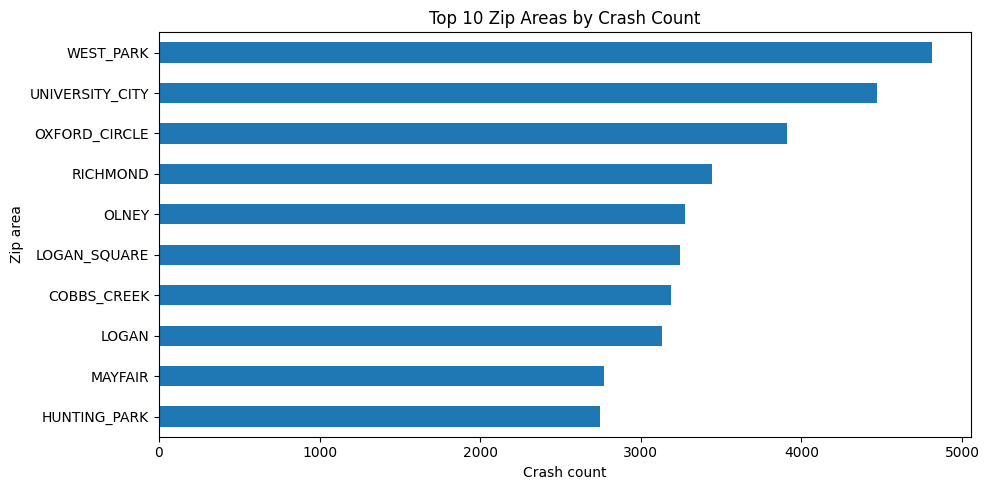

In [12]:
zip_shapes = gpd.read_file("philadelphia_zip_boundaries.geojson")

philly_map = philly[
    philly["DEC_LONGITUDE"].between(-75.35, -74.9) &
    philly["DEC_LATITUDE"].between(39.8, 40.2)
].copy()

geo = gpd.GeoDataFrame(
    philly_map,
    geometry=gpd.points_from_xy(philly_map["DEC_LONGITUDE"], philly_map["DEC_LATITUDE"]),
    crs="EPSG:4326"
)

joined = gpd.sjoin(
    geo,
    zip_shapes[["name", "geometry"]],
    how="left",
    predicate="within"
)

top_zip_crashes = joined.groupby("name").size().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_zip_crashes.sort_values().plot(kind="barh")
plt.title("Top 10 Zip Areas by Crash Count")
plt.xlabel("Crash count")
plt.ylabel("Zip area")
plt.tight_layout()
plt.show()


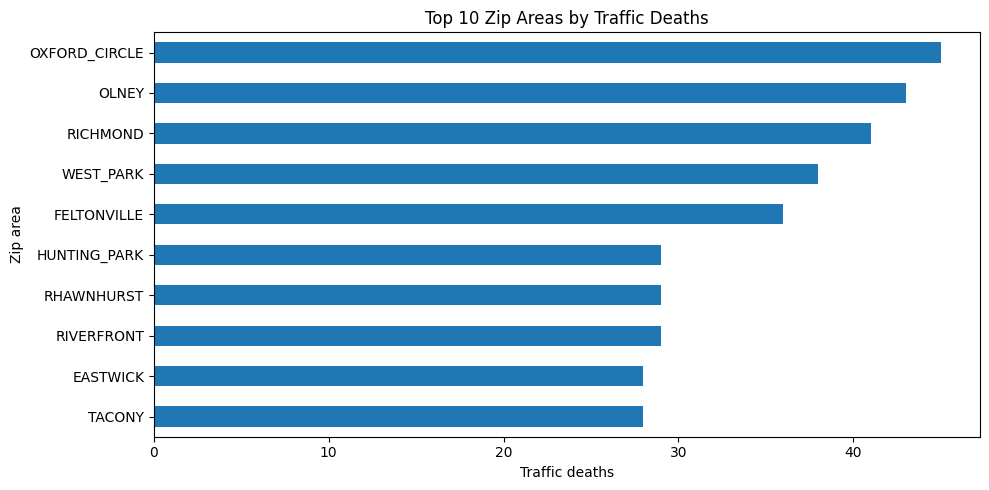

In [13]:
top_zip_fatalities = joined.groupby("name")["FATAL_COUNT"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_zip_fatalities.sort_values().plot(kind="barh")
plt.title("Top 10 Zip Areas by Traffic Deaths")
plt.xlabel("Traffic deaths")
plt.ylabel("Zip area")
plt.tight_layout()
plt.show()
